# Meta Feature Analysis - Part 1 (Fold Level)

This is a fold-level copy of `01_mfa.ipynb`. It keeps the same preprocessing and reporting flow, but treats each `(dataset, repeat, fold)` row as the analysis unit and exports both Spearman and Pearson association tables.


# Data Loading

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

notebook_dir = Path.cwd()
project_dir = notebook_dir.parent
repo_root = project_dir.parent

sys.path.insert(0, str(project_dir / "src"))
sys.path.insert(0, str(repo_root / "tabarena" / "tabarena"))


def _project_dir_for_notebook_handoff() -> Path:
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd.parent,
        cwd / "meta-feature-analysis",
    ]
    for candidate in candidates:
        if (candidate / "src" / "mfa").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError(
        "Run this notebook from the repository root or notebooks/ directory."
    )

In [ ]:
CONFIG = "config_1.yaml"

# Downstream cells use this method for the default `general_associations`,
# `classification_associations`, and robust/sensitivity artifacts. Both methods
# are still computed and exported as method-specific tables.
ACTIVE_ASSOCIATION_METHOD = "spearman"  # choose: "spearman" or "pearson"
ASSOCIATION_METHODS = ("spearman", "pearson")

In [ ]:
from dataclasses import replace
import json
import uuid
import pandas as pd

from mfa import load_config
from mfa.cache import compute_config_hash
from mfa.types import AnalysisUnit

config_path = project_dir / "configs" / CONFIG
config = load_config(config_path)

# Read the configured value from YAML.
yaml_n_jobs = config.parallelism.n_jobs

# Keep this notebook safe: use at most two workers for this run.
effective_n_jobs = min(yaml_n_jobs, 2) if yaml_n_jobs > 0 else 2

# Build a temporary config override for this run only (does not edit YAML).
# This notebook is intentionally fold-level, while 01_mfa.ipynb remains dataset-level.
run_config = replace(
    config,
    analysis=replace(config.analysis, unit=AnalysisUnit.FOLD),
    parallelism=replace(config.parallelism, n_jobs=effective_n_jobs),
)

MFA_PROJECT_DIR = _project_dir_for_notebook_handoff()
MFA_CONFIG_HASH = compute_config_hash(run_config.to_dict())
MFA_RUN_ID = uuid.uuid4().hex[:12]
MFA_HANDOFF_DIR = (
    MFA_PROJECT_DIR
    / ".mfa_cache"
    / "notebook_handoff_fold_level"
    / f"{config_path.stem}_{MFA_CONFIG_HASH}_{MFA_RUN_ID}"
)
MFA_HANDOFF_EXPECTED_TABLES = (
    "analysis_general_reduced",
    "analysis_classification_reduced",
)
MFA_HANDOFF_REQUIRED_FILES = [MFA_HANDOFF_DIR / "metadata.json"] + [
    MFA_HANDOFF_DIR / f"{table_name}.pkl" for table_name in MFA_HANDOFF_EXPECTED_TABLES
]
MFA_HANDOFF_MISSING_FILES = [
    path for path in MFA_HANDOFF_REQUIRED_FILES if not path.exists()
]
MFA_HANDOFF_CACHE_READY = False


def _mfa_handoff_table_path(table_name: str) -> Path:
    return MFA_HANDOFF_DIR / f"{table_name}.pkl"


def _mfa_load_handoff_table(table_name: str) -> pd.DataFrame | None:
    path = _mfa_handoff_table_path(table_name)
    if not path.exists():
        return None
    print(f"Loaded cached notebook handoff table `{table_name}` from {path}.")
    return pd.read_pickle(path)


if yaml_n_jobs != effective_n_jobs:
    print(
        f"Loaded {config_path.name}; parallelism.n_jobs={yaml_n_jobs}. "
        f"Temporarily using n_jobs={effective_n_jobs} for this fold-level run."
    )
else:
    print(
        f"Loaded {config_path.name}; parallelism.n_jobs={yaml_n_jobs}. "
        "Proceeding with the fold-level analysis."
    )

print(
    "Fold-level handoff artifacts will be written to a fresh run directory: "
    f"{MFA_HANDOFF_DIR}"
)
print(
    "This notebook does not reuse prior notebook handoff artifacts, even when "
    "the same YAML config is selected."
)

Loaded config_1.yaml; parallelism.n_jobs=-1. Temporarily using n_jobs=2 for this fold-level run.
Fold-level handoff artifacts will be written to a fresh run directory: /work/mherre/tabular-meta-feature-analysis/meta-feature-analysis/.mfa_cache/notebook_handoff_fold_level/config_1_e3be3b3ae5862186_b1d27d0e20b7
This notebook does not reuse prior notebook handoff artifacts, even when the same YAML config is selected.


In [4]:
from mfa import run_analysis
from mfa.types import AnalysisResult
from tabarena.nips2025_utils.fetch_metadata import load_task_metadata

_result_cache_names = (
    "result_gap_table",
    "result_metafeature_table",
    "result_analysis_table",
)
_result_cache = {name: _mfa_load_handoff_table(name) for name in _result_cache_names}
if all(table is not None for table in _result_cache.values()):
    result = AnalysisResult(
        config_hash=MFA_CONFIG_HASH,
        comparison_name=(
            run_config.comparisons[0].name if len(run_config.comparisons) == 1 else None
        ),
        gap_table=_result_cache["result_gap_table"],
        metafeature_table=_result_cache["result_metafeature_table"],
        analysis_table=_result_cache["result_analysis_table"],
    )
else:
    result = run_analysis(run_config)

    task_type_lookup = (
        load_task_metadata()[["dataset", "problem_type"]]
        .rename(columns={"problem_type": "task_type"})
        .drop_duplicates(subset="dataset")
    )
    result.metafeature_table = result.metafeature_table.merge(
        task_type_lookup, on="dataset", how="left", validate="many_to_one"
    )
    result.analysis_table = result.analysis_table.merge(
        task_type_lookup, on="dataset", how="left", validate="many_to_one"
    )
result.analysis_table.head()

11:03:41 INFO mfa.pipeline: Starting analysis: comparisons=non_foundational_vs_foundational; scope=all benchmark datasets; unit=fold; method_variant=default,tuned; n_jobs=2
11:03:41 INFO mfa.pipeline: Stage 1/4 raw results: cache hit (34110 rows, 51 dataset(s))
11:03:41 INFO mfa.pipeline: Stage 2/4 meta-features: trace enabled; metafeature caches remain active, so live per-split diagnostics appear only on cache misses
11:03:41 INFO mfa.pipeline: Stage 2/4 meta-features: pymfe enabled; rebuilding from split cache and reusing cached failures/incomplete outputs as-is
11:03:41 INFO mfa.pipeline: Stage 2/4 meta-features: building for all benchmark datasets
11:03:41 INFO mfa.metafeatures: Meta-features: preparing 51 dataset(s) with feature_sets=basic,redundancy,pymfe (n_jobs=2)
11:03:41 INFO mfa.metafeatures: Meta-features: trace enabled; split cache remains active, so live timing and warning diagnostics appear only on cache misses
11:03:41 INFO mfa.metafeatures: Meta-features: trace enabled

,dataset,repeat,fold,n,d,log_n,log_d,n_over_d,d_over_n,n_num_features,...,expected_direction,best_a_method,best_a_error,best_a_norm_error,best_b_method,best_b_error,best_b_norm_error,delta_raw,delta_norm,task_type
0,APSFailure,0,0,50666,170,4.704717,2.230449,298.035294,0.003355,170,...,None,REALMLP_GPU (tuned),0.006935,1.000000,TABICLV2 (default),0.004507,0.0,0.002428,1.000000,binary
1,APSFailure,0,1,50667,170,4.704725,2.230449,298.041176,0.003355,170,...,None,XGB (tuned),0.009461,0.913448,TABICLV2 (default),0.006703,0.0,0.002758,0.913448,binary
2,APSFailure,0,2,50667,170,4.704725,2.230449,298.041176,0.003355,170,...,None,REALMLP_GPU (tuned),0.010800,1.000000,TABDPT_GPU (tuned),0.011852,1.0,-0.001052,0.000000,binary
3,APSFailure,1,0,50666,170,4.704717,2.230449,298.035294,0.003355,170,...,None,GBM (tuned),0.011383,0.701761,TABICLV2 (default),0.008698,0.0,0.002685,0.701761,binary
4,APSFailure,1,1,50667,170,4.704725,2.230449,298.041176,0.003355,170,...,None,REALMLP_GPU (tuned),0.005822,0.434777,TABDPT_GPU (tuned),0.008121,1.0,-0.002300,-0.565223,binary


# Preprocessing

In [5]:
import pandas as pd

# -- Inspect what the result object contains --
print(f"config_hash:        {result.config_hash}")
print(f"comparison_name:    {result.comparison_name}")
print(f"analysis_table:     {result.analysis_table.shape}")
print(f"gap_table:          {result.gap_table.shape}")
print(f"metafeature_table:  {result.metafeature_table.shape}")
print(f"correlation_results: {len(result.correlation_results)} features tested")
print(
    f"correction_result:  {result.correction_result.method if result.correction_result else None}"
)
print(f"multivariate_result: {result.multivariate_result}")

config_hash:        e3be3b3ae5862186
comparison_name:    non_foundational_vs_foundational
analysis_table:     (816, 1132)
gap_table:          (816, 17)
metafeature_table:  (816, 1118)
correlation_results: 0 features tested
correction_result:  None
multivariate_result: None


## Build Task-Aware Analysis Tables

We construct two analysis matrices because the available meta-features depend on the supervised task type. The general matrix contains only features that are meaningful for both regression and classification tasks. The classification matrix is restricted to classification tasks and augments the general feature set with class-label-dependent features such as class counts, entropy, imbalance, and Pymfe classification-only descriptors.

The two matrices are analyzed separately downstream, so their preprocessing filters are estimated within their own task populations rather than forcing the classification-specific analysis to inherit decisions from the full regression-plus-classification table.

In [ ]:
import numpy as np

from mfa.metafeatures.basic import (
    CLASSIFICATION_PROBLEM_TYPES as BASIC_CLASSIFICATION_PROBLEM_TYPES,
)
from mfa.metafeatures.pymfe_catalog import PYMFE_CLASSIFICATION_ONLY
from mfa.stats.correlation import EXCLUDED_PREDICTOR_COLUMNS

BASIC_CLASSIFICATION_ONLY_FEATURES = frozenset(
    {
        "n_classes",
        "class_entropy",
        "majority_class_fraction",
        "minority_class_fraction",
        "class_imbalance_ratio",
    }
)
CLASSIFICATION_PROBLEM_TYPES = set(BASIC_CLASSIFICATION_PROBLEM_TYPES)

if {"dataset", "repeat", "fold"}.issubset(result.analysis_table.columns):
    result.analysis_table = result.analysis_table.copy()
    result.analysis_table["analysis_unit_id"] = (
        result.analysis_table["dataset"].astype(str)
        + "__r"
        + result.analysis_table["repeat"].astype(int).astype(str)
        + "__f"
        + result.analysis_table["fold"].astype(int).astype(str)
    )
else:
    raise KeyError("Fold-level analysis requires dataset, repeat, and fold columns.")


ANALYSIS_CONTEXT_COLUMNS = [
    "analysis_unit_id",
    "dataset",
    "repeat",
    "fold",
    "task_type",
    "comparison_name",
    "group_a_name",
    "group_b_name",
    "group_a_label",
    "group_b_label",
    "expected_direction",
    "n_splits",
    "best_a_error",
    "best_a_norm_error",
    "best_b_error",
    "best_b_norm_error",
    "delta_raw",
    "delta_raw_std",
    "delta_raw_sem",
    "delta_norm",
    "delta_norm_std",
    "delta_norm_sem",
]


def _is_pymfe_classification_only(column: str) -> bool:
    if not column.startswith("pymfe__"):
        return False
    raw_feature = column.removeprefix("pymfe__").split(".", maxsplit=1)[0]
    return raw_feature in PYMFE_CLASSIFICATION_ONLY


def is_classification_only_feature(column: str) -> bool:
    return (
        column in BASIC_CLASSIFICATION_ONLY_FEATURES
        or _is_pymfe_classification_only(column)
    )


def infer_numeric_predictors(
    table: pd.DataFrame, *, target: str = "delta_norm"
) -> list[str]:
    predictors = []
    for column in table.columns:
        if (
            column == target
            or column in EXCLUDED_PREDICTOR_COLUMNS
            or column.startswith("best_")
        ):
            continue
        numeric_values = pd.to_numeric(table[column], errors="coerce")
        if pd.api.types.is_numeric_dtype(table[column]) or numeric_values.notna().any():
            predictors.append(column)
    return predictors


available_context_columns = [
    column
    for column in ANALYSIS_CONTEXT_COLUMNS
    if column in result.analysis_table.columns
]
_excluded_from_predictors = set(ANALYSIS_CONTEXT_COLUMNS)
all_predictor_columns = [
    column
    for column in infer_numeric_predictors(result.analysis_table)
    if column not in _excluded_from_predictors
]
shared_predictor_columns = [
    column
    for column in all_predictor_columns
    if not is_classification_only_feature(column)
]
classification_only_predictor_columns = [
    column for column in all_predictor_columns if is_classification_only_feature(column)
]
classification_predictor_columns = [
    *shared_predictor_columns,
    *classification_only_predictor_columns,
]

task_type = result.analysis_table["task_type"].astype("string").str.lower()
classification_mask = task_type.isin(CLASSIFICATION_PROBLEM_TYPES)

analysis_general_raw = result.analysis_table.loc[
    :, available_context_columns + shared_predictor_columns
].copy()
analysis_classification_raw = result.analysis_table.loc[
    classification_mask, available_context_columns + classification_predictor_columns
].copy()

feature_table_summary = pd.DataFrame(
    [
        {
            "table": "general_regression_and_classification",
            "rows": len(analysis_general_raw),
            "predictor_columns": len(shared_predictor_columns),
            "classification_only_predictors": 0,
        },
        {
            "table": "classification_augmented",
            "rows": len(analysis_classification_raw),
            "predictor_columns": len(classification_predictor_columns),
            "classification_only_predictors": len(
                classification_only_predictor_columns
            ),
        },
    ]
)

display(feature_table_summary)
print(
    f"Shared predictors retained before preprocessing: {len(shared_predictor_columns)}"
)
print(
    f"Classification-only predictors available before preprocessing: {len(classification_only_predictor_columns)}"
)

,table,rows,predictor_columns,classification_only_predictors
0,general_regression_and_classification,816,544,0
1,classification_augmented,594,1114,570


Shared predictors retained before preprocessing: 544
Classification-only predictors available before preprocessing: 570


## Preprocess Analysis Tables

For each analysis matrix, infinite values are treated as missing values before feature filtering. We then remove features with high missingness and features with negligible empirical variation. The near-constant filter removes exact constants, numerically constant features under a tight relative tolerance, and features where one rounded value dominates at least 95% of non-missing observations. These rules are unsupervised and are applied independently to the general and classification-specific matrices.

In [7]:
MAX_FEATURE_MISSINGNESS = 0.20
NEAR_CONSTANT_TOP_SHARE = 0.95
NUMERICAL_CONSTANT_REL_TOL = 1e-12


def _near_constant_report(
    table: pd.DataFrame,
    feature_columns: list[str],
    *,
    top_share_threshold: float = NEAR_CONSTANT_TOP_SHARE,
    numerical_constant_rel_tol: float = NUMERICAL_CONSTANT_REL_TOL,
) -> pd.DataFrame:
    rows = []
    for column in feature_columns:
        values = pd.to_numeric(table[column], errors="coerce").dropna()
        n_non_missing = int(values.shape[0])
        if n_non_missing == 0:
            rows.append(
                {
                    "feature": column,
                    "n_non_missing": n_non_missing,
                    "n_unique": 0,
                    "top_share": np.nan,
                    "reason": "all_missing_after_inf_replacement",
                }
            )
            continue

        n_unique = int(values.nunique(dropna=True))
        rounded_values = values.round(12)
        top_share = float(
            rounded_values.value_counts(normalize=True, dropna=True).iloc[0]
        )
        scale = max(1.0, float(values.abs().median()))
        numerical_span = float(values.max() - values.min())

        reason = None
        if n_unique <= 1:
            reason = "exact_constant"
        elif numerical_span <= numerical_constant_rel_tol * scale:
            reason = "numerical_constant"
        elif top_share >= top_share_threshold:
            reason = "dominant_value_share_ge_0.95"

        if reason is not None:
            rows.append(
                {
                    "feature": column,
                    "n_non_missing": n_non_missing,
                    "n_unique": n_unique,
                    "top_share": top_share,
                    "reason": reason,
                }
            )
    return pd.DataFrame(rows)


def preprocess_analysis_table(
    table: pd.DataFrame,
    feature_columns: list[str],
    *,
    table_name: str,
    max_feature_missingness: float = MAX_FEATURE_MISSINGNESS,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    cleaned = table.copy()
    for column in cleaned.columns:
        numeric_values = pd.to_numeric(cleaned[column], errors="coerce")
        if (
            pd.api.types.is_numeric_dtype(cleaned[column])
            or numeric_values.notna().any()
        ):
            cleaned[column] = numeric_values.replace([np.inf, -np.inf], np.nan)
    feature_columns = [
        column for column in feature_columns if column in cleaned.columns
    ]

    missing_fraction = (
        cleaned[feature_columns].isna().mean().sort_values(ascending=False)
    )
    high_missing_features = missing_fraction[
        missing_fraction > max_feature_missingness
    ].index.tolist()
    after_missingness = [
        column for column in feature_columns if column not in high_missing_features
    ]

    near_constant = _near_constant_report(cleaned, after_missingness)
    near_constant_features = (
        near_constant["feature"].tolist() if not near_constant.empty else []
    )
    retained_features = [
        column for column in after_missingness if column not in near_constant_features
    ]

    context_columns = [
        column for column in available_context_columns if column in cleaned.columns
    ]
    processed = cleaned.loc[:, context_columns + retained_features].copy()

    report_rows = []
    for feature in high_missing_features:
        report_rows.append(
            {
                "table": table_name,
                "stage": "high_missingness",
                "feature": feature,
                "missing_fraction": float(missing_fraction.loc[feature]),
                "reason": f"> {max_feature_missingness:.0%} missing",
            }
        )
    if not near_constant.empty:
        near_constant = near_constant.assign(table=table_name, stage="near_constant")
        near_constant["missing_fraction"] = (
            near_constant["feature"].map(missing_fraction).astype(float)
        )
        report_rows.extend(
            near_constant[
                [
                    "table",
                    "stage",
                    "feature",
                    "missing_fraction",
                    "n_non_missing",
                    "n_unique",
                    "top_share",
                    "reason",
                ]
            ].to_dict("records")
        )

    report = pd.DataFrame(report_rows)
    print(
        f"{table_name}: rows={len(processed)}, predictors={len(retained_features)} "
        f"(dropped {len(high_missing_features)} high-missing, {len(near_constant_features)} near-constant)"
    )
    return processed, report


analysis_general, general_preprocessing_report = preprocess_analysis_table(
    analysis_general_raw,
    shared_predictor_columns,
    table_name="general_regression_and_classification",
)
analysis_classification, classification_preprocessing_report = (
    preprocess_analysis_table(
        analysis_classification_raw,
        classification_predictor_columns,
        table_name="classification_augmented",
    )
)

preprocessing_report = pd.concat(
    [general_preprocessing_report, classification_preprocessing_report],
    ignore_index=True,
)
preprocessing_summary = pd.DataFrame(
    [
        {
            "table": "general_regression_and_classification",
            "rows": len(analysis_general),
            "columns": analysis_general.shape[1],
            "predictors_after_preprocessing": analysis_general.shape[1]
            - len(available_context_columns),
        },
        {
            "table": "classification_augmented",
            "rows": len(analysis_classification),
            "columns": analysis_classification.shape[1],
            "predictors_after_preprocessing": analysis_classification.shape[1]
            - len(available_context_columns),
        },
    ]
)

display(preprocessing_summary)
display(preprocessing_report)

general_regression_and_classification: rows=816, predictors=493 (dropped 49 high-missing, 2 near-constant)
classification_augmented: rows=594, predictors=1027 (dropped 53 high-missing, 34 near-constant)


,table,rows,columns,predictors_after_preprocessing
0,general_regression_and_classification,816,510,493
1,classification_augmented,594,1044,1027


,table,stage,feature,missing_fraction,reason,n_non_missing,n_unique,top_share
0,general_regression_and_classification,high_missingness,pymfe__num_to_cat,0.352941,> 20% missing,NaN,NaN,NaN
1,general_regression_and_classification,high_missingness,pymfe__h_mean.kurtosis,0.348039,> 20% missing,NaN,NaN,NaN
2,general_regression_and_classification,high_missingness,pymfe__h_mean.skewness,0.348039,> 20% missing,NaN,NaN,NaN
3,general_regression_and_classification,high_missingness,pymfe__g_mean.skewness,0.345588,> 20% missing,NaN,NaN,NaN
4,general_regression_and_classification,high_missingness,pymfe__g_mean.kurtosis,0.345588,> 20% missing,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
133,classification_augmented,near_constant,pymfe__linear_discr.count,0.060606,dominant_value_share_ge_0.95,558.0,2.0,0.971326
134,classification_augmented,near_constant,pymfe__naive_bayes.count,0.057239,exact_constant,560.0,1.0,1.000000
135,classification_augmented,near_constant,pymfe__one_nn.count,0.057239,exact_constant,560.0,1.0,1.000000
136,classification_augmented,near_constant,pymfe__random_node.count,0.057239,exact_constant,560.0,1.0,1.000000


## Reduce Redundant Features

We reduce redundancy using only feature-feature relationships, not the downstream performance target. Within each analysis matrix, we compute absolute Spearman correlations among the preprocessed predictors and remove one feature from pairs with near-duplicate rank behavior. For each highly correlated pair, the retained feature is chosen deterministically by lower missingness, then more unique observed values, then column name. This keeps the filter unsupervised, reproducible, scale-invariant, and separately calibrated to the general and classification-specific analysis populations.

In [8]:
REDUNDANCY_SPEARMAN_THRESHOLD = 0.95


def _redundancy_feature_columns(table: pd.DataFrame) -> list[str]:
    return [
        column
        for column in table.columns
        if column not in available_context_columns and column != "delta_norm"
    ]


def _prefer_feature(
    feature_a: str,
    feature_b: str,
    *,
    missing_fraction: pd.Series,
    n_unique: pd.Series,
) -> tuple[str, str]:
    key_a = (
        float(missing_fraction.loc[feature_a]),
        -int(n_unique.loc[feature_a]),
        feature_a,
    )
    key_b = (
        float(missing_fraction.loc[feature_b]),
        -int(n_unique.loc[feature_b]),
        feature_b,
    )
    if key_a <= key_b:
        return feature_a, feature_b
    return feature_b, feature_a


def reduce_redundant_features(
    table: pd.DataFrame,
    *,
    table_name: str,
    threshold: float = REDUNDANCY_SPEARMAN_THRESHOLD,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    feature_columns = _redundancy_feature_columns(table)
    if len(feature_columns) <= 1:
        return table.copy(), pd.DataFrame()

    numeric_features = table[feature_columns].apply(pd.to_numeric, errors="coerce")
    missing_fraction = numeric_features.isna().mean()
    n_unique = numeric_features.nunique(dropna=True)
    corr = numeric_features.corr(method="spearman", min_periods=3).abs()

    high_corr_pairs = []
    for i, feature_a in enumerate(feature_columns):
        for feature_b in feature_columns[i + 1 :]:
            abs_spearman = corr.loc[feature_a, feature_b]
            if pd.notna(abs_spearman) and abs_spearman >= threshold:
                high_corr_pairs.append((float(abs_spearman), feature_a, feature_b))
    high_corr_pairs.sort(key=lambda row: (-row[0], row[1], row[2]))

    dropped_features: set[str] = set()
    report_rows = []
    for abs_spearman, feature_a, feature_b in high_corr_pairs:
        if feature_a in dropped_features or feature_b in dropped_features:
            continue

        kept_feature, dropped_feature = _prefer_feature(
            feature_a,
            feature_b,
            missing_fraction=missing_fraction,
            n_unique=n_unique,
        )
        dropped_features.add(dropped_feature)
        report_rows.append(
            {
                "table": table_name,
                "stage": "redundancy",
                "dropped_feature": dropped_feature,
                "kept_feature": kept_feature,
                "abs_spearman": abs_spearman,
                "dropped_missing_fraction": float(
                    missing_fraction.loc[dropped_feature]
                ),
                "kept_missing_fraction": float(missing_fraction.loc[kept_feature]),
                "dropped_n_unique": int(n_unique.loc[dropped_feature]),
                "kept_n_unique": int(n_unique.loc[kept_feature]),
                "reason": f"abs_spearman >= {threshold:.2f}",
            }
        )

    retained_features = [
        feature for feature in feature_columns if feature not in dropped_features
    ]
    context_columns = [
        column for column in available_context_columns if column in table
    ]
    reduced = table.loc[:, context_columns + retained_features].copy()
    report = pd.DataFrame(report_rows)
    print(
        f"{table_name}: rows={len(reduced)}, predictors={len(retained_features)} "
        f"(dropped {len(dropped_features)} redundant)"
    )
    return reduced, report


_redundancy_cache_names = (
    "analysis_general_reduced",
    "analysis_classification_reduced",
    "general_redundancy_report",
    "classification_redundancy_report",
    "redundancy_report",
    "redundancy_summary",
)
_redundancy_cache = {
    name: _mfa_load_handoff_table(name) for name in _redundancy_cache_names
}
if all(table is not None for table in _redundancy_cache.values()):
    analysis_general_reduced = _redundancy_cache["analysis_general_reduced"]
    analysis_classification_reduced = _redundancy_cache[
        "analysis_classification_reduced"
    ]
    general_redundancy_report = _redundancy_cache["general_redundancy_report"]
    classification_redundancy_report = _redundancy_cache[
        "classification_redundancy_report"
    ]
    redundancy_report = _redundancy_cache["redundancy_report"]
    redundancy_summary = _redundancy_cache["redundancy_summary"]
else:
    analysis_general_reduced, general_redundancy_report = reduce_redundant_features(
        analysis_general,
        table_name="general_regression_and_classification",
    )
    analysis_classification_reduced, classification_redundancy_report = (
        reduce_redundant_features(
            analysis_classification,
            table_name="classification_augmented",
        )
    )

    redundancy_report = pd.concat(
        [general_redundancy_report, classification_redundancy_report],
        ignore_index=True,
    )
    redundancy_summary = pd.DataFrame(
        [
            {
                "table": "general_regression_and_classification",
                "rows": len(analysis_general_reduced),
                "columns": analysis_general_reduced.shape[1],
                "predictors_after_redundancy_reduction": len(
                    _redundancy_feature_columns(analysis_general_reduced)
                ),
                "predictors_dropped_as_redundant": len(general_redundancy_report),
            },
            {
                "table": "classification_augmented",
                "rows": len(analysis_classification_reduced),
                "columns": analysis_classification_reduced.shape[1],
                "predictors_after_redundancy_reduction": len(
                    _redundancy_feature_columns(analysis_classification_reduced)
                ),
                "predictors_dropped_as_redundant": len(
                    classification_redundancy_report
                ),
            },
        ]
    )

display(redundancy_summary)
display(redundancy_report)

general_regression_and_classification: rows=816, predictors=293 (dropped 200 redundant)
classification_augmented: rows=594, predictors=592 (dropped 435 redundant)


,table,rows,columns,predictors_after_redundancy_reduction,predictors_dropped_as_redundant
0,general_regression_and_classification,816,310,293,200
1,classification_augmented,594,609,592,435


,table,stage,dropped_feature,kept_feature,abs_spearman,dropped_missing_fraction,kept_missing_fraction,dropped_n_unique,kept_n_unique,reason
0,general_regression_and_classification,redundancy,pymfe__cat_to_num,cat_fraction,1.000000,0.080882,0.000000,26,27,abs_spearman >= 0.95
1,general_regression_and_classification,redundancy,log_d,d,1.000000,0.000000,0.000000,35,35,abs_spearman >= 0.95
2,general_regression_and_classification,redundancy,pymfe__attr_ent.count,d,1.000000,0.011029,0.000000,34,35,abs_spearman >= 0.95
3,general_regression_and_classification,redundancy,pymfe__nr_attr,d,1.000000,0.011029,0.000000,34,35,abs_spearman >= 0.95
4,general_regression_and_classification,redundancy,pymfe__sparsity.count,d,1.000000,0.049020,0.000000,33,35,abs_spearman >= 0.95
...,...,...,...,...,...,...,...,...,...,...
630,classification_augmented,redundancy,pymfe__nodes_repeated.skewness,pymfe__nodes_repeated.kurtosis,0.951911,0.038721,0.038721,563,565,abs_spearman >= 0.95
631,classification_augmented,redundancy,pymfe__leaves_corrob.mean,pymfe__tree_shape.mean,0.951831,0.038721,0.038721,336,567,abs_spearman >= 0.95
632,classification_augmented,redundancy,pymfe__attr_ent.median,pymfe__attr_ent.mean,0.951337,0.015152,0.015152,565,585,abs_spearman >= 0.95
633,classification_augmented,redundancy,pymfe__leaves_homo.min,pymfe__tree_shape.sd,0.951147,0.038721,0.038721,334,567,abs_spearman >= 0.95


## Estimate Feature-Performance Associations

We now analyze the two reduced matrices separately at the dataset level. Each row must correspond to one independent dataset; split-level rows or repeated datasets would inflate significance and therefore fail the guard below. For each retained meta-feature with at least 30 paired datasets, we estimate its monotonic association with normalized performance difference (`delta_norm`) using Spearman correlation. P-values are adjusted with Benjamini-Hochberg FDR within each analysis table. Dataset-bootstrap confidence intervals and sign-consistency diagnostics are computed for all tested features. For the reported top features, we also record bootstrap rank stability after ranking against the full tested feature set. This keeps the inferential step separate from preprocessing: missingness filtering, near-constant filtering, and redundancy reduction were all target-agnostic.

In [ ]:
from scipy import stats
from statsmodels.stats.multitest import multipletests


ASSOCIATION_TARGET = "delta_norm"
ASSOCIATION_MIN_N = 30
ASSOCIATION_ALPHA = 0.05
ASSOCIATION_BOOTSTRAP_REPEATS = 500
ASSOCIATION_CI_TOP_K = None
ASSOCIATION_RANK_STABILITY_TOP_K = 25
ASSOCIATION_RANDOM_SEED = 20260424
INDEPENDENT_UNIT_COLUMN = "analysis_unit_id"
VALID_ASSOCIATION_METHODS = ("spearman", "pearson")
ASSOCIATION_METHODS = tuple(
    dict.fromkeys(
        method.lower()
        for method in globals().get("ASSOCIATION_METHODS", VALID_ASSOCIATION_METHODS)
    )
)
ACTIVE_ASSOCIATION_METHOD = (
    globals().get("ACTIVE_ASSOCIATION_METHOD", ASSOCIATION_METHODS[0]).lower()
)
if ACTIVE_ASSOCIATION_METHOD not in VALID_ASSOCIATION_METHODS:
    raise ValueError(
        f"ACTIVE_ASSOCIATION_METHOD must be one of {VALID_ASSOCIATION_METHODS}."
    )
invalid_methods = [
    method for method in ASSOCIATION_METHODS if method not in VALID_ASSOCIATION_METHODS
]
if invalid_methods:
    raise ValueError(
        f"ASSOCIATION_METHODS contains invalid methods: {invalid_methods}."
    )
if ACTIVE_ASSOCIATION_METHOD not in ASSOCIATION_METHODS:
    ASSOCIATION_METHODS = (ACTIVE_ASSOCIATION_METHOD, *ASSOCIATION_METHODS)

ASSOCIATION_METHOD_LABELS = {
    "spearman": "Spearman",
    "pearson": "Pearson",
}


def assert_analysis_unit_table(
    table: pd.DataFrame,
    *,
    table_name: str,
    unit_column: str = INDEPENDENT_UNIT_COLUMN,
) -> dict[str, int | str]:
    if unit_column not in table.columns:
        raise KeyError(
            f"{table_name} is missing the analysis unit column: {unit_column}"
        )

    n_rows = len(table)
    n_units = table[unit_column].nunique(dropna=False)
    duplicate_mask = table[unit_column].duplicated(keep=False)
    if duplicate_mask.any():
        duplicate_units = (
            table.loc[duplicate_mask, unit_column].drop_duplicates().head(10).tolist()
        )
        raise ValueError(
            f"{table_name} is not one-row-per-fold-analysis-unit: {n_rows} rows but "
            f"{n_units} unique {unit_column} values. Repeated examples: {duplicate_units}."
        )

    return {
        "table": table_name,
        "independent_unit": unit_column,
        "rows": n_rows,
        "unique_units": n_units,
        "note": "Fold rows are treated as analysis units; folds from the same dataset are not independent.",
    }


def _association_feature_columns(table: pd.DataFrame) -> list[str]:
    return [
        column
        for column in table.columns
        if column not in available_context_columns and column != ASSOCIATION_TARGET
    ]


def _correlation_result(
    x: np.ndarray, y: np.ndarray, *, method: str
) -> tuple[float, float]:
    if method == "spearman":
        result = stats.spearmanr(x, y)
    elif method == "pearson":
        result = stats.pearsonr(x, y)
    else:
        raise ValueError(f"Unsupported association method: {method}")
    return float(result.statistic), float(result.pvalue)


def _bootstrap_correlation_summary(
    x_values: np.ndarray,
    y_values: np.ndarray,
    *,
    method: str,
    rng: np.random.Generator,
    n_repeats: int,
    alpha: float,
    observed_r: float,
) -> tuple[float, float, float, int]:
    n = len(x_values)
    bootstrap_r = []
    for _ in range(n_repeats):
        sample_idx = rng.integers(0, n, size=n)
        sample_x = x_values[sample_idx]
        sample_y = y_values[sample_idx]
        if np.unique(sample_x).size < 2 or np.unique(sample_y).size < 2:
            continue
        statistic, _ = _correlation_result(sample_x, sample_y, method=method)
        if np.isfinite(statistic):
            bootstrap_r.append(float(statistic))

    if len(bootstrap_r) < 20:
        return np.nan, np.nan, np.nan, len(bootstrap_r)

    bootstrap_r = np.asarray(bootstrap_r, dtype=float)
    ci_low, ci_high = np.quantile(bootstrap_r, [alpha / 2, 1 - alpha / 2])
    observed_sign = np.sign(observed_r)
    sign_consistency = (
        np.mean(np.sign(bootstrap_r) == observed_sign) if observed_sign != 0 else np.nan
    )
    return float(ci_low), float(ci_high), float(sign_consistency), len(bootstrap_r)


def _bootstrap_rank_stability(
    table: pd.DataFrame,
    associations: pd.DataFrame,
    *,
    method: str,
    target: str,
    min_n: int,
    n_repeats: int,
    top_k: int,
    random_seed: int,
) -> pd.DataFrame:
    tested = associations.loc[
        associations["correlation_r"].notna(), ["feature", "correlation_r"]
    ]
    if tested.empty:
        return pd.DataFrame(
            columns=[
                "feature",
                "bootstrap_rank_median",
                "bootstrap_rank_q05",
                "bootstrap_rank_q95",
                "bootstrap_top_k_frequency",
            ]
        )

    tracked_features = tested.head(top_k)["feature"].tolist()
    rank_records = {feature: [] for feature in tracked_features}
    top_k_hits = {feature: 0 for feature in tracked_features}
    feature_values = {
        feature: pd.to_numeric(table[feature], errors="coerce").to_numpy(dtype=float)
        for feature in tested["feature"]
    }
    target_values = pd.to_numeric(table[target], errors="coerce").to_numpy(dtype=float)
    rng = np.random.default_rng(random_seed)

    for _ in range(n_repeats):
        sample_idx = rng.integers(0, len(table), size=len(table))
        replicate_rows = []
        sample_y_all = target_values[sample_idx]
        for feature, values in feature_values.items():
            sample_x_all = values[sample_idx]
            valid = np.isfinite(sample_x_all) & np.isfinite(sample_y_all)
            if valid.sum() < min_n:
                continue
            sample_x = sample_x_all[valid]
            sample_y = sample_y_all[valid]
            if np.unique(sample_x).size < 2 or np.unique(sample_y).size < 2:
                continue
            statistic, _ = _correlation_result(sample_x, sample_y, method=method)
            if np.isfinite(statistic):
                replicate_rows.append((feature, abs(float(statistic))))

        if not replicate_rows:
            continue

        replicate_ranks = pd.Series(
            {feature: abs_r for feature, abs_r in replicate_rows}
        ).rank(method="first", ascending=False)
        replicate_top = set(replicate_ranks[replicate_ranks <= top_k].index)
        for feature in tracked_features:
            if feature in replicate_ranks.index:
                rank_records[feature].append(float(replicate_ranks[feature]))
                top_k_hits[feature] += int(feature in replicate_top)

    rows = []
    for feature in tracked_features:
        ranks = np.asarray(rank_records[feature], dtype=float)
        if len(ranks) < 20:
            rank_median = np.nan
            rank_q05 = np.nan
            rank_q95 = np.nan
            top_k_frequency = np.nan
        else:
            rank_q05, rank_median, rank_q95 = np.quantile(ranks, [0.05, 0.5, 0.95])
            top_k_frequency = top_k_hits[feature] / len(ranks)
        rows.append(
            {
                "feature": feature,
                "bootstrap_rank_median": rank_median,
                "bootstrap_rank_q05": rank_q05,
                "bootstrap_rank_q95": rank_q95,
                "bootstrap_top_k_frequency": top_k_frequency,
            }
        )
    return pd.DataFrame(rows)


def estimate_feature_associations(
    table: pd.DataFrame,
    *,
    table_name: str,
    method: str,
    target: str = ASSOCIATION_TARGET,
    min_n: int = ASSOCIATION_MIN_N,
    bootstrap_repeats: int = ASSOCIATION_BOOTSTRAP_REPEATS,
    ci_top_k: int | None = ASSOCIATION_CI_TOP_K,
    rank_stability_top_k: int = ASSOCIATION_RANK_STABILITY_TOP_K,
    alpha: float = ASSOCIATION_ALPHA,
    random_seed: int = ASSOCIATION_RANDOM_SEED,
) -> pd.DataFrame:
    assert_analysis_unit_table(table, table_name=table_name)
    feature_columns = _association_feature_columns(table)
    target_values = pd.to_numeric(table[target], errors="coerce")
    rows = []

    for feature in feature_columns:
        feature_values = pd.to_numeric(table[feature], errors="coerce")
        valid = feature_values.notna() & target_values.notna()
        x = feature_values.loc[valid].to_numpy(dtype=float)
        y = target_values.loc[valid].to_numpy(dtype=float)
        n = len(x)
        feature_n_unique = int(pd.Series(x).nunique(dropna=True)) if n else 0
        target_n_unique = int(pd.Series(y).nunique(dropna=True)) if n else 0

        if n < min_n:
            correlation_r = np.nan
            p_value = np.nan
            reason = f"n < {min_n}"
        elif feature_n_unique < 2:
            correlation_r = np.nan
            p_value = np.nan
            reason = "feature has <2 observed values"
        elif target_n_unique < 2:
            correlation_r = np.nan
            p_value = np.nan
            reason = "target has <2 observed values"
        else:
            correlation_r, p_value = _correlation_result(x, y, method=method)
            reason = "tested"

        row = {
            "table": table_name,
            "correlation_method": method,
            "feature": feature,
            "n": n,
            "feature_n_unique": feature_n_unique,
            "correlation_r": correlation_r,
            "abs_correlation_r": (
                abs(correlation_r) if np.isfinite(correlation_r) else np.nan
            ),
            "p_value": p_value,
            "p_value_bh": np.nan,
            "bh_reject_0_05": False,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "bootstrap_sign_consistency": np.nan,
            "bootstrap_repeats_used": 0,
            "reason": reason,
        }
        row[f"{method}_r"] = correlation_r
        row[f"abs_{method}_r"] = row["abs_correlation_r"]
        rows.append(row)

    associations = pd.DataFrame(rows)
    valid_p = associations["p_value"].notna()
    if valid_p.any():
        reject, adjusted_p, _, _ = multipletests(
            associations.loc[valid_p, "p_value"],
            alpha=alpha,
            method="fdr_bh",
        )
        associations.loc[valid_p, "p_value_bh"] = adjusted_p
        associations.loc[valid_p, "bh_reject_0_05"] = reject

    associations = associations.sort_values(
        ["abs_correlation_r", "feature"],
        ascending=[False, True],
        na_position="last",
    ).reset_index(drop=True)
    associations["effect_rank"] = np.arange(1, len(associations) + 1)

    ci_features = associations.loc[associations["correlation_r"].notna(), "feature"]
    if ci_top_k is not None:
        ci_features = ci_features.head(ci_top_k)
    for rank_idx, feature in enumerate(ci_features):
        feature_values = pd.to_numeric(table[feature], errors="coerce")
        valid = feature_values.notna() & target_values.notna()
        x = feature_values.loc[valid].to_numpy(dtype=float)
        y = target_values.loc[valid].to_numpy(dtype=float)
        rng = np.random.default_rng(random_seed + rank_idx)
        observed_r = float(
            associations.loc[associations["feature"] == feature, "correlation_r"].iloc[
                0
            ]
        )
        ci_low, ci_high, sign_consistency, repeats_used = (
            _bootstrap_correlation_summary(
                x,
                y,
                method=method,
                rng=rng,
                n_repeats=bootstrap_repeats,
                alpha=alpha,
                observed_r=observed_r,
            )
        )
        row_idx = associations.index[associations["feature"] == feature][0]
        associations.loc[row_idx, "ci_low"] = ci_low
        associations.loc[row_idx, "ci_high"] = ci_high
        associations.loc[row_idx, "bootstrap_sign_consistency"] = sign_consistency
        associations.loc[row_idx, "bootstrap_repeats_used"] = repeats_used

    rank_stability = _bootstrap_rank_stability(
        table,
        associations,
        method=method,
        target=target,
        min_n=min_n,
        n_repeats=bootstrap_repeats,
        top_k=rank_stability_top_k,
        random_seed=random_seed + 100_000,
    )
    associations = associations.merge(rank_stability, on="feature", how="left")

    print(
        f"{table_name} ({method}): tested {valid_p.sum()} predictors; "
        f"{associations['bh_reject_0_05'].sum()} pass BH FDR at alpha={alpha}"
    )
    return associations


_association_cache_names = (
    "association_unit_summary",
    "general_associations",
    "classification_associations",
    "association_results",
    "association_summary",
    "all_method_association_results",
)
for method in ASSOCIATION_METHODS:
    _association_cache_names += (
        f"general_{method}_associations",
        f"classification_{method}_associations",
        f"{method}_association_results",
    )
_association_cache = {
    name: _mfa_load_handoff_table(name) for name in _association_cache_names
}
if all(table is not None for table in _association_cache.values()):
    association_unit_summary = _association_cache["association_unit_summary"]
    general_associations = _association_cache["general_associations"]
    classification_associations = _association_cache["classification_associations"]
    association_results = _association_cache["association_results"]
    association_summary = _association_cache["association_summary"]
    all_method_association_results = _association_cache[
        "all_method_association_results"
    ]
    for method in ASSOCIATION_METHODS:
        globals()[f"general_{method}_associations"] = _association_cache[
            f"general_{method}_associations"
        ]
        globals()[f"classification_{method}_associations"] = _association_cache[
            f"classification_{method}_associations"
        ]
        globals()[f"{method}_association_results"] = _association_cache[
            f"{method}_association_results"
        ]
else:
    association_unit_summary = pd.DataFrame(
        [
            assert_analysis_unit_table(
                analysis_general_reduced,
                table_name="general_regression_and_classification",
            ),
            assert_analysis_unit_table(
                analysis_classification_reduced,
                table_name="classification_augmented",
            ),
        ]
    )

    method_result_frames = []
    summary_rows = []
    for method in ASSOCIATION_METHODS:
        general_method_associations = estimate_feature_associations(
            analysis_general_reduced,
            table_name="general_regression_and_classification",
            method=method,
        )
        classification_method_associations = estimate_feature_associations(
            analysis_classification_reduced,
            table_name="classification_augmented",
            method=method,
        )
        method_association_results = pd.concat(
            [general_method_associations, classification_method_associations],
            ignore_index=True,
        )
        globals()[f"general_{method}_associations"] = general_method_associations
        globals()[
            f"classification_{method}_associations"
        ] = classification_method_associations
        globals()[f"{method}_association_results"] = method_association_results
        method_result_frames.append(method_association_results)

        summary_rows.extend(
            [
                {
                    "table": "general_regression_and_classification",
                    "correlation_method": method,
                    "predictors_tested": general_method_associations["p_value"]
                    .notna()
                    .sum(),
                    "bh_reject_0_05": general_method_associations[
                        "bh_reject_0_05"
                    ].sum(),
                    "max_abs_correlation_r": general_method_associations[
                        "abs_correlation_r"
                    ].max(),
                    "median_bootstrap_sign_consistency": general_method_associations[
                        "bootstrap_sign_consistency"
                    ].median(),
                    "median_top_25_frequency": general_method_associations[
                        "bootstrap_top_k_frequency"
                    ].median(),
                    "is_active_method": method == ACTIVE_ASSOCIATION_METHOD,
                },
                {
                    "table": "classification_augmented",
                    "correlation_method": method,
                    "predictors_tested": classification_method_associations["p_value"]
                    .notna()
                    .sum(),
                    "bh_reject_0_05": classification_method_associations[
                        "bh_reject_0_05"
                    ].sum(),
                    "max_abs_correlation_r": classification_method_associations[
                        "abs_correlation_r"
                    ].max(),
                    "median_bootstrap_sign_consistency": classification_method_associations[
                        "bootstrap_sign_consistency"
                    ].median(),
                    "median_top_25_frequency": classification_method_associations[
                        "bootstrap_top_k_frequency"
                    ].median(),
                    "is_active_method": method == ACTIVE_ASSOCIATION_METHOD,
                },
            ]
        )

    general_associations = globals()[
        f"general_{ACTIVE_ASSOCIATION_METHOD}_associations"
    ]
    classification_associations = globals()[
        f"classification_{ACTIVE_ASSOCIATION_METHOD}_associations"
    ]
    association_results = globals()[f"{ACTIVE_ASSOCIATION_METHOD}_association_results"]
    all_method_association_results = pd.concat(method_result_frames, ignore_index=True)
    association_summary = pd.DataFrame(summary_rows)

print(
    f"Active association method for downstream artifacts: {ACTIVE_ASSOCIATION_METHOD}"
)
display(association_unit_summary)
display(association_summary)
display(general_associations.head(25))
display(classification_associations.head(25))

general_regression_and_classification (spearman): tested 293 predictors; 172 pass BH FDR at alpha=0.05
classification_augmented (spearman): tested 592 predictors; 307 pass BH FDR at alpha=0.05
general_regression_and_classification (pearson): tested 293 predictors; 134 pass BH FDR at alpha=0.05
classification_augmented (pearson): tested 592 predictors; 269 pass BH FDR at alpha=0.05
Active association method for downstream artifacts: spearman


,table,independent_unit,rows,unique_units,note
0,general_regression_and_classification,analysis_unit_id,816,816,Fold rows are treated as analysis units; folds...
1,classification_augmented,analysis_unit_id,594,594,Fold rows are treated as analysis units; folds...


,table,correlation_method,predictors_tested,bh_reject_0_05,max_abs_correlation_r,median_bootstrap_sign_consistency,median_top_25_frequency,is_active_method
0,general_regression_and_classification,spearman,293,172,0.316133,0.996,0.680,True
1,classification_augmented,spearman,592,307,0.392951,0.990,0.620,True
2,general_regression_and_classification,pearson,293,134,0.284557,0.992,0.652,False
3,classification_augmented,pearson,592,269,0.399473,0.987,0.678,False


,table,correlation_method,feature,n,feature_n_unique,correlation_r,abs_correlation_r,p_value,p_value_bh,bh_reject_0_05,...,bootstrap_sign_consistency,bootstrap_repeats_used,reason,spearman_r,abs_spearman_r,effect_rank,bootstrap_rank_median,bootstrap_rank_q05,bootstrap_rank_q95,bootstrap_top_k_frequency
0,general_regression_and_classification,spearman,pymfe__attr_ent.skewness,807,807,-0.316133,0.316133,3.455958e-20,1.012596e-17,True,...,1.0,500,tested,-0.316133,0.316133,1,1.0,1.00,4.00,1.000
1,general_regression_and_classification,spearman,pymfe__cor.histogram.2,764,327,0.270708,0.270708,2.680798e-14,3.927369e-12,True,...,1.0,500,tested,0.270708,0.270708,2,4.0,1.00,12.00,0.998
2,general_regression_and_classification,spearman,pymfe__cor.histogram.3,764,290,0.265083,0.265083,9.426051e-14,9.206110e-12,True,...,1.0,500,tested,0.265083,0.265083,3,5.0,2.00,16.05,0.982
3,general_regression_and_classification,spearman,pymfe__cor.histogram.6,764,203,0.257547,0.257547,4.851925e-13,2.369357e-11,True,...,1.0,500,tested,0.257547,0.257547,4,6.0,1.00,27.00,0.942
4,general_regression_and_classification,spearman,pymfe__attr_ent.histogram.0,807,66,-0.256515,0.256515,1.362960e-13,9.983684e-12,True,...,1.0,500,tested,-0.256515,0.256515,5,6.0,2.00,28.00,0.942
5,general_regression_and_classification,spearman,pymfe__attr_conc.quantiles.1,807,807,0.252195,0.252195,3.567499e-13,2.090555e-11,True,...,1.0,500,tested,0.252195,0.252195,6,7.0,2.00,26.05,0.948
6,general_regression_and_classification,spearman,pymfe__sparsity.skewness,767,670,0.248966,0.248966,2.667272e-12,9.768884e-11,True,...,1.0,500,tested,0.248966,0.248966,7,7.0,2.00,31.05,0.928
7,general_regression_and_classification,spearman,pymfe__attr_ent.histogram.9,807,66,0.247407,0.247407,1.014797e-12,4.247648e-11,True,...,1.0,500,tested,0.247407,0.247407,8,8.0,2.00,26.05,0.946
8,general_regression_and_classification,spearman,pymfe__cor.max,764,486,-0.231541,0.231541,9.314354e-11,3.032340e-09,True,...,1.0,500,tested,-0.231541,0.231541,9,12.0,3.00,44.00,0.816
9,general_regression_and_classification,spearman,pymfe__cor.histogram.1,764,380,0.219132,0.219132,9.265639e-10,2.468029e-08,True,...,1.0,500,tested,0.219132,0.219132,10,18.0,5.00,60.00,0.680


,table,correlation_method,feature,n,feature_n_unique,correlation_r,abs_correlation_r,p_value,p_value_bh,bh_reject_0_05,...,bootstrap_sign_consistency,bootstrap_repeats_used,reason,spearman_r,abs_spearman_r,effect_rank,bootstrap_rank_median,bootstrap_rank_q05,bootstrap_rank_q95,bootstrap_top_k_frequency
0,classification_augmented,spearman,pymfe__cor.max,547,314,-0.392951,0.392951,1.218731e-21,7.214889e-19,True,...,1.0,500,tested,-0.392951,0.392951,1,1.0,1.00,7.00,0.998
1,classification_augmented,spearman,pymfe__attr_ent.skewness,585,585,-0.349620,0.349620,2.917317e-18,8.635257e-16,True,...,1.0,500,tested,-0.349620,0.349620,2,4.0,1.00,14.00,0.992
2,classification_augmented,spearman,pymfe__best_node.iq_range,560,340,0.343851,0.343851,5.496735e-17,1.084689e-14,True,...,1.0,500,tested,0.343851,0.343851,3,5.0,1.00,19.05,0.972
3,classification_augmented,spearman,pymfe__cor.range,547,526,-0.343359,0.343359,1.400564e-16,2.072835e-14,True,...,1.0,500,tested,-0.343359,0.343359,4,5.0,2.00,26.00,0.946
4,classification_augmented,spearman,pymfe__joint_ent.skewness,585,585,-0.330804,0.330804,2.096789e-16,2.482599e-14,True,...,1.0,500,tested,-0.330804,0.330804,5,7.0,2.00,24.00,0.956
5,classification_augmented,spearman,pymfe__cor.histogram.6,547,179,0.326796,0.326796,4.435635e-15,4.376493e-13,True,...,1.0,500,tested,0.326796,0.326796,6,8.0,2.00,27.05,0.942
6,classification_augmented,spearman,pymfe__sparsity.skewness,551,501,0.320822,0.320822,1.175880e-14,9.944587e-13,True,...,1.0,500,tested,0.320822,0.320822,7,8.0,1.95,40.05,0.886
7,classification_augmented,spearman,pymfe__cor.histogram.3,547,255,0.320066,0.320066,1.702706e-14,1.260003e-12,True,...,1.0,500,tested,0.320066,0.320066,8,8.0,3.00,29.05,0.928
8,classification_augmented,spearman,pymfe__linear_discr.sd,542,542,0.302331,0.302331,6.420509e-13,3.455401e-11,True,...,1.0,500,tested,0.302331,0.302331,9,15.0,3.00,56.00,0.760
9,classification_augmented,spearman,pymfe__tree_shape.histogram.6,571,366,0.295183,0.295183,6.058950e-13,3.455401e-11,True,...,1.0,500,tested,0.295183,0.295183,10,16.5,3.00,61.10,0.696


## Select Robust Univariate Associations

We use the association analysis as a reporting step before interpretation or multivariable adjustment. A feature is reported when it passes Benjamini-Hochberg FDR (`q < 0.05`) and has stable bootstrap direction (`bootstrap_sign_consistency >= 0.90`). Reported features are ranked by absolute Spearman association. Bootstrap confidence intervals and rank-stability diagnostics are reported as robustness diagnostics, not as additional hypothesis tests. The regression+classification and classification-augmented matrices are reported separately.

In [ ]:
ROBUST_ASSOCIATION_Q_THRESHOLD = 0.05
ROBUST_ASSOCIATION_MIN_SIGN_CONSISTENCY = 0.90
ROBUST_ASSOCIATION_TOP_N = 25


ROBUST_ASSOCIATION_OUTPUT_COLUMNS = [
    "feature",
    "n",
    "correlation_method",
    "correlation_r",
    "abs_correlation_r",
    "p_value_bh",
    "ci_low",
    "ci_high",
    "bootstrap_sign_consistency",
    "bootstrap_rank_median",
    "bootstrap_rank_q05",
    "bootstrap_rank_q95",
    "bootstrap_top_k_frequency",
]

ROBUST_ASSOCIATION_COLUMN_NAMES = {
    "feature": "feature",
    "n": "n",
    "correlation_method": "association_method",
    "correlation_r": "association_r",
    "abs_correlation_r": "abs_association_r",
    "p_value_bh": "bh_q_value",
    "ci_low": "bootstrap_ci_low",
    "ci_high": "bootstrap_ci_high",
    "bootstrap_sign_consistency": "bootstrap_sign_consistency",
    "bootstrap_rank_median": "bootstrap_rank_median",
    "bootstrap_rank_q05": "bootstrap_rank_q05",
    "bootstrap_rank_q95": "bootstrap_rank_q95",
    "bootstrap_top_k_frequency": "bootstrap_top_25_frequency",
}


def build_robust_association_table(
    associations: pd.DataFrame,
    *,
    table_name: str,
    q_threshold: float = ROBUST_ASSOCIATION_Q_THRESHOLD,
    min_sign_consistency: float = ROBUST_ASSOCIATION_MIN_SIGN_CONSISTENCY,
    top_n: int = ROBUST_ASSOCIATION_TOP_N,
) -> pd.DataFrame:
    required_columns = {
        "feature",
        "n",
        "correlation_method",
        "correlation_r",
        "abs_correlation_r",
        "p_value",
        "p_value_bh",
        "ci_low",
        "ci_high",
        "bootstrap_sign_consistency",
        "bootstrap_rank_median",
        "bootstrap_rank_q05",
        "bootstrap_rank_q95",
        "bootstrap_top_k_frequency",
    }
    missing_columns = sorted(required_columns.difference(associations.columns))
    if missing_columns:
        raise KeyError(
            f"{table_name} associations are missing required columns: {missing_columns}"
        )

    tested = associations.loc[associations["p_value"].notna()].copy()
    robust = tested.loc[
        tested["p_value_bh"].lt(q_threshold)
        & tested["bootstrap_sign_consistency"].ge(min_sign_consistency)
    ].copy()

    robust = robust.sort_values(
        ["abs_correlation_r", "bootstrap_sign_consistency", "feature"],
        ascending=[False, False, True],
    )

    output_columns = [
        column
        for column in ROBUST_ASSOCIATION_OUTPUT_COLUMNS
        if column in robust.columns
    ]
    table = (
        robust.loc[:, output_columns]
        .head(top_n)
        .rename(columns=ROBUST_ASSOCIATION_COLUMN_NAMES)
    )
    table.insert(0, "analysis_table", table_name)
    return table.reset_index(drop=True)


_robust_cache_names = (
    "robust_general_associations",
    "robust_classification_associations",
    "robust_association_summary",
    "robust_associations",
)
_robust_cache = {name: _mfa_load_handoff_table(name) for name in _robust_cache_names}
if all(table is not None for table in _robust_cache.values()):
    robust_general_associations = _robust_cache["robust_general_associations"]
    robust_classification_associations = _robust_cache[
        "robust_classification_associations"
    ]
    robust_association_summary = _robust_cache["robust_association_summary"]
    robust_associations = _robust_cache["robust_associations"]
else:
    robust_general_associations = build_robust_association_table(
        general_associations,
        table_name="regression_classification",
    )
    robust_classification_associations = build_robust_association_table(
        classification_associations,
        table_name="classification_augmented",
    )

    robust_association_summary = pd.DataFrame(
        [
            {
                "analysis_table": "regression_classification",
                "association_method": ACTIVE_ASSOCIATION_METHOD,
                "tested_predictors": general_associations["p_value"].notna().sum(),
                "reported_features": len(robust_general_associations),
                "q_threshold": ROBUST_ASSOCIATION_Q_THRESHOLD,
                "min_bootstrap_sign_consistency": ROBUST_ASSOCIATION_MIN_SIGN_CONSISTENCY,
            },
            {
                "analysis_table": "classification_augmented",
                "association_method": ACTIVE_ASSOCIATION_METHOD,
                "tested_predictors": classification_associations["p_value"]
                .notna()
                .sum(),
                "reported_features": len(robust_classification_associations),
                "q_threshold": ROBUST_ASSOCIATION_Q_THRESHOLD,
                "min_bootstrap_sign_consistency": ROBUST_ASSOCIATION_MIN_SIGN_CONSISTENCY,
            },
        ]
    )

    robust_associations = pd.concat(
        [robust_general_associations, robust_classification_associations],
        ignore_index=True,
    )

robust_association_tables = {
    "regression_classification": robust_general_associations,
    "classification_augmented": robust_classification_associations,
}


display(robust_association_summary)
display(robust_general_associations)
display(robust_classification_associations)

,analysis_table,association_method,tested_predictors,reported_features,q_threshold,min_bootstrap_sign_consistency
0,regression_classification,spearman,293,25,0.05,0.9
1,classification_augmented,spearman,592,25,0.05,0.9


,analysis_table,feature,n,association_method,association_r,abs_association_r,bh_q_value,bootstrap_ci_low,bootstrap_ci_high,bootstrap_sign_consistency,bootstrap_rank_median,bootstrap_rank_q05,bootstrap_rank_q95,bootstrap_top_25_frequency
0,regression_classification,pymfe__attr_ent.skewness,807,spearman,-0.316133,0.316133,1.012596e-17,-0.374743,-0.258750,1.0,1.0,1.00,4.00,1.000
1,regression_classification,pymfe__cor.histogram.2,764,spearman,0.270708,0.270708,3.927369e-12,0.205659,0.333196,1.0,4.0,1.00,12.00,0.998
2,regression_classification,pymfe__cor.histogram.3,764,spearman,0.265083,0.265083,9.206110e-12,0.190824,0.322039,1.0,5.0,2.00,16.05,0.982
3,regression_classification,pymfe__cor.histogram.6,764,spearman,0.257547,0.257547,2.369357e-11,0.193843,0.323846,1.0,6.0,1.00,27.00,0.942
4,regression_classification,pymfe__attr_ent.histogram.0,807,spearman,-0.256515,0.256515,9.983684e-12,-0.320839,-0.184809,1.0,6.0,2.00,28.00,0.942
5,regression_classification,pymfe__attr_conc.quantiles.1,807,spearman,0.252195,0.252195,2.090555e-11,0.186118,0.315690,1.0,7.0,2.00,26.05,0.948
6,regression_classification,pymfe__sparsity.skewness,767,spearman,0.248966,0.248966,9.768884e-11,0.184739,0.309385,1.0,7.0,2.00,31.05,0.928
7,regression_classification,pymfe__attr_ent.histogram.9,807,spearman,0.247407,0.247407,4.247648e-11,0.178723,0.305352,1.0,8.0,2.00,26.05,0.946
8,regression_classification,pymfe__cor.max,764,spearman,-0.231541,0.231541,3.032340e-09,-0.300208,-0.157415,1.0,12.0,3.00,44.00,0.816
9,regression_classification,pymfe__cor.histogram.1,764,spearman,0.219132,0.219132,2.468029e-08,0.144614,0.285354,1.0,18.0,5.00,60.00,0.680


,analysis_table,feature,n,association_method,association_r,abs_association_r,bh_q_value,bootstrap_ci_low,bootstrap_ci_high,bootstrap_sign_consistency,bootstrap_rank_median,bootstrap_rank_q05,bootstrap_rank_q95,bootstrap_top_25_frequency
0,classification_augmented,pymfe__cor.max,547,spearman,-0.392951,0.392951,7.214889e-19,-0.465126,-0.318015,1.0,1.0,1.00,7.00,0.998
1,classification_augmented,pymfe__attr_ent.skewness,585,spearman,-0.349620,0.349620,8.635257e-16,-0.413982,-0.281610,1.0,4.0,1.00,14.00,0.992
2,classification_augmented,pymfe__best_node.iq_range,560,spearman,0.343851,0.343851,1.084689e-14,0.266990,0.420430,1.0,5.0,1.00,19.05,0.972
3,classification_augmented,pymfe__cor.range,547,spearman,-0.343359,0.343359,2.072835e-14,-0.422411,-0.263982,1.0,5.0,2.00,26.00,0.946
4,classification_augmented,pymfe__joint_ent.skewness,585,spearman,-0.330804,0.330804,2.482599e-14,-0.407709,-0.254090,1.0,7.0,2.00,24.00,0.956
5,classification_augmented,pymfe__cor.histogram.6,547,spearman,0.326796,0.326796,4.376493e-13,0.259805,0.392454,1.0,8.0,2.00,27.05,0.942
6,classification_augmented,pymfe__sparsity.skewness,551,spearman,0.320822,0.320822,9.944587e-13,0.237104,0.396316,1.0,8.0,1.95,40.05,0.886
7,classification_augmented,pymfe__cor.histogram.3,547,spearman,0.320066,0.320066,1.260003e-12,0.251405,0.401232,1.0,8.0,3.00,29.05,0.928
8,classification_augmented,pymfe__linear_discr.sd,542,spearman,0.302331,0.302331,3.455401e-11,0.214922,0.379297,1.0,15.0,3.00,56.00,0.760
9,classification_augmented,pymfe__tree_shape.histogram.6,571,spearman,0.295183,0.295183,3.455401e-11,0.219934,0.372434,1.0,16.5,3.00,61.10,0.696


## Visualize Reported Association

For lookback, we visualize the top reported robust association from the regression+classification matrix. Each point is one fold-level analysis unit. The fitted line is descriptive only; inference remains based on the active fold-level correlation method, BH-FDR correction, and bootstrap diagnostics reported above.


Saved scatterplot to /work/mherre/tabular-meta-feature-analysis/meta-feature-analysis/.mfa_cache/notebook_handoff_fold_level/config_1_e3be3b3ae5862186_b1d27d0e20b7/association_scatter_spearman_pymfe__attr_ent.skewness.png


,feature,n,association_method,association_r,bh_q_value,bootstrap_ci_low,bootstrap_ci_high,bootstrap_sign_consistency,bootstrap_top_25_frequency
0,pymfe__attr_ent.skewness,807,spearman,-0.316133,1.012596e-17,-0.374743,-0.25875,1.0,1.0


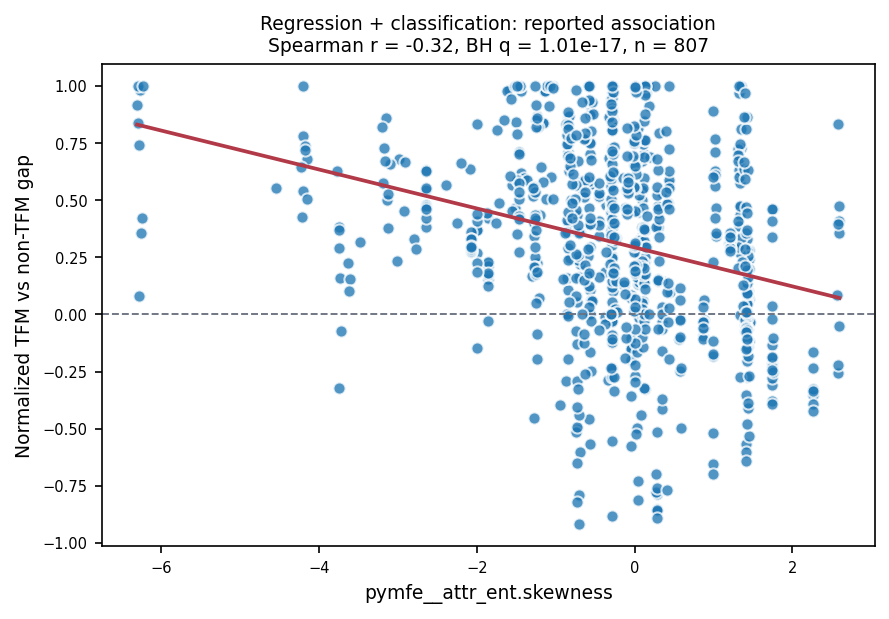

In [ ]:
import re

import matplotlib.pyplot as plt
import seaborn as sns


ASSOCIATION_SCATTER_TABLE_NAME = "regression_classification"
if robust_general_associations.empty:
    ASSOCIATION_SCATTER_FEATURE = None
    association_scatter_data = pd.DataFrame()
    association_scatter_summary = pd.DataFrame(
        [
            {
                "analysis_table": ASSOCIATION_SCATTER_TABLE_NAME,
                "message": (
                    "No robust/significant meta-feature associations remain under the "
                    "predefined reporting rule; scatterplot skipped."
                ),
                "q_threshold": ROBUST_ASSOCIATION_Q_THRESHOLD,
                "min_bootstrap_sign_consistency": ROBUST_ASSOCIATION_MIN_SIGN_CONSISTENCY,
                "association_method": ACTIVE_ASSOCIATION_METHOD,
                "tested_predictors": general_associations["p_value"].notna().sum(),
            }
        ]
    )
    association_scatter_output_path = None
    print(association_scatter_summary.loc[0, "message"])
    display(association_scatter_summary)
else:
    ASSOCIATION_SCATTER_FEATURE = robust_general_associations.iloc[0]["feature"]

    if ASSOCIATION_SCATTER_FEATURE not in analysis_general_reduced.columns:
        raise KeyError(
            f"{ASSOCIATION_SCATTER_FEATURE!r} is not present in analysis_general_reduced."
        )

    association_scatter_data = analysis_general_reduced.loc[
        :, [INDEPENDENT_UNIT_COLUMN, ASSOCIATION_TARGET, ASSOCIATION_SCATTER_FEATURE]
    ].copy()
    association_scatter_data[ASSOCIATION_TARGET] = pd.to_numeric(
        association_scatter_data[ASSOCIATION_TARGET], errors="coerce"
    )
    association_scatter_data[ASSOCIATION_SCATTER_FEATURE] = pd.to_numeric(
        association_scatter_data[ASSOCIATION_SCATTER_FEATURE], errors="coerce"
    )
    association_scatter_data = association_scatter_data.replace(
        [np.inf, -np.inf], np.nan
    )
    association_scatter_data = association_scatter_data.dropna().reset_index(drop=True)

    association_scatter_summary = general_associations.loc[
        general_associations["feature"].eq(ASSOCIATION_SCATTER_FEATURE),
        [
            "feature",
            "n",
            "correlation_method",
            "correlation_r",
            "p_value_bh",
            "ci_low",
            "ci_high",
            "bootstrap_sign_consistency",
            "bootstrap_top_k_frequency",
        ],
    ].rename(
        columns={
            "correlation_method": "association_method",
            "correlation_r": "association_r",
            "p_value_bh": "bh_q_value",
            "ci_low": "bootstrap_ci_low",
            "ci_high": "bootstrap_ci_high",
            "bootstrap_top_k_frequency": "bootstrap_top_25_frequency",
        }
    )

    if association_scatter_summary.empty:
        raise ValueError(
            f"No association result found for {ASSOCIATION_SCATTER_FEATURE!r}."
        )

    row = association_scatter_summary.iloc[0]
    fig, ax = plt.subplots(figsize=(6.0, 4.2), dpi=150)
    sns.regplot(
        data=association_scatter_data,
        x=ASSOCIATION_SCATTER_FEATURE,
        y=ASSOCIATION_TARGET,
        ci=None,
        scatter_kws={"s": 34, "alpha": 0.78, "edgecolor": "white"},
        line_kws={"color": "#b23a48", "linewidth": 1.8},
        ax=ax,
    )
    ax.axhline(0, color="#6b7280", linewidth=0.9, linestyle="--")
    ax.set_xlabel(ASSOCIATION_SCATTER_FEATURE)
    ax.set_ylabel("Normalized TFM vs non-TFM gap")
    method_label = ASSOCIATION_METHOD_LABELS.get(
        row.get("association_method", ACTIVE_ASSOCIATION_METHOD),
        str(row.get("association_method", ACTIVE_ASSOCIATION_METHOD)).title(),
    )
    ax.set_title(
        "Regression + classification: reported association\n"
        f"{method_label} r = {row['association_r']:.2f}, "
        f"BH q = {row['bh_q_value']:.3g}, "
        f"n = {int(row['n'])}"
    )
    fig.tight_layout()

    safe_feature_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", ASSOCIATION_SCATTER_FEATURE)
    association_scatter_output_path = (
        globals().get(
            "MFA_HANDOFF_DIR",
            _project_dir_for_notebook_handoff()
            / ".mfa_cache"
            / "notebook_handoff_fold_level",
        )
        / f"association_scatter_{ACTIVE_ASSOCIATION_METHOD}_{safe_feature_name}.png"
    )
    association_scatter_output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(association_scatter_output_path, bbox_inches="tight")

    print(f"Saved scatterplot to {association_scatter_output_path}")
    display(association_scatter_summary)
    plt.show()

## Constrained Sensitivity Step

We treat multivariable modeling as a sensitivity analysis rather than a confirmatory inference step. Its purpose is to assess whether the direction of previously identified robust univariate associations remains stable under joint adjustment for other reported signals and basic dataset characteristics. Candidate features come only from the pre-specified robust univariate reporting rule. To avoid overparameterization, we use at most one representative feature per meta-feature family and cap the total number of predictors, including controls. Controls are fixed a priori and included whenever available. We report adjusted rank-scale coefficients, bootstrap confidence intervals, and bootstrap sign consistency; no new multiplicity correction or discovery claims are made in this step.

In [ ]:
import numpy as np
import pandas as pd


SENSITIVITY_TARGET = globals().get("ASSOCIATION_TARGET", "delta_norm")
SENSITIVITY_UNIT_COLUMN = globals().get("INDEPENDENT_UNIT_COLUMN", "dataset")
SENSITIVITY_MIN_N = globals().get("ASSOCIATION_MIN_N", 30)
SENSITIVITY_ALPHA = 0.05
SENSITIVITY_BOOTSTRAP_REPEATS = 500
SENSITIVITY_RANDOM_SEED = globals().get("ASSOCIATION_RANDOM_SEED", 20260424)
SENSITIVITY_MAX_TOTAL_PREDICTORS = 8
SENSITIVITY_MAX_FEATURE_PREDICTORS = 3
SENSITIVITY_MIN_SIGN_CONSISTENCY = 0.90

SENSITIVITY_GENERAL_CONTROL_CANDIDATES = [
    ("n_samples", ("n_samples", "n_instances", "n_rows", "n")),
    ("n_features", ("n_features", "n_columns", "n_attrs", "n_attr", "d")),
    (
        "feature_sample_ratio",
        ("d_over_n", "n_features_over_n_samples", "features_per_sample"),
    ),
]

SENSITIVITY_CLASSIFICATION_CONTROL_CANDIDATES = [
    ("n_classes", ("n_classes", "nr_classes")),
    (
        "class_imbalance_ratio",
        ("class_imbalance_ratio", "imbalance_ratio", "majority_minority_ratio"),
    ),
]


def _sensitivity_feature_family(feature: str) -> str:
    if feature.startswith("pymfe__"):
        return feature.split(".", maxsplit=1)[0]
    return feature


def _select_one_feature_per_family(
    robust_table: pd.DataFrame,
    *,
    max_features: int,
) -> tuple[list[str], pd.DataFrame]:
    if robust_table.empty or max_features <= 0:
        return [], pd.DataFrame(
            columns=["feature", "feature_family", "selection_status"]
        )

    required_columns = {"feature", "abs_association_r", "bootstrap_sign_consistency"}
    missing_columns = sorted(required_columns.difference(robust_table.columns))
    if missing_columns:
        raise KeyError(
            f"Robust association table is missing columns: {missing_columns}"
        )

    candidates = robust_table.copy()
    candidates["feature_family"] = candidates["feature"].map(
        _sensitivity_feature_family
    )
    candidates = candidates.sort_values(
        ["abs_association_r", "bootstrap_sign_consistency", "feature"],
        ascending=[False, False, True],
    )
    family_representatives = candidates.drop_duplicates(
        "feature_family", keep="first"
    ).copy()
    selected = family_representatives.head(max_features).copy()
    selected_features = selected["feature"].tolist()

    report = candidates.loc[:, ["feature", "feature_family"]].copy()
    report["selection_status"] = np.select(
        [
            report["feature"].isin(selected_features),
            report["feature_family"].isin(selected["feature_family"]),
        ],
        ["selected", "same_family_as_selected"],
        default="excluded_by_model_cap",
    )
    return selected_features, report


def _assert_analysis_unit_for_sensitivity(
    table: pd.DataFrame, *, table_name: str
) -> None:
    if SENSITIVITY_UNIT_COLUMN not in table.columns:
        raise KeyError(f"{table_name} is missing {SENSITIVITY_UNIT_COLUMN!r}")
    duplicates = table[SENSITIVITY_UNIT_COLUMN].duplicated(keep=False)
    if duplicates.any():
        examples = (
            table.loc[duplicates, SENSITIVITY_UNIT_COLUMN]
            .drop_duplicates()
            .head(10)
            .tolist()
        )
        raise ValueError(
            f"{table_name} is not one-row-per-analysis-unit; repeated {SENSITIVITY_UNIT_COLUMN} examples: {examples}"
        )


def _available_controls(
    control_source_table: pd.DataFrame,
    *,
    include_classification_controls: bool,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    candidate_groups = list(SENSITIVITY_GENERAL_CONTROL_CANDIDATES)
    if include_classification_controls:
        candidate_groups.extend(SENSITIVITY_CLASSIFICATION_CONTROL_CANDIDATES)

    controls = pd.DataFrame(
        {SENSITIVITY_UNIT_COLUMN: control_source_table[SENSITIVITY_UNIT_COLUMN]}
    )
    report_rows = []
    for control_name, candidates in candidate_groups:
        source_column = next(
            (column for column in candidates if column in control_source_table.columns),
            None,
        )
        if source_column is None:
            report_rows.append(
                {
                    "control": control_name,
                    "source_column": np.nan,
                    "included": False,
                    "reason": "not_available",
                }
            )
            continue

        values = pd.to_numeric(control_source_table[source_column], errors="coerce")
        if values.notna().sum() < SENSITIVITY_MIN_N or values.nunique(dropna=True) < 2:
            report_rows.append(
                {
                    "control": control_name,
                    "source_column": source_column,
                    "included": False,
                    "reason": "insufficient_variation_or_n",
                }
            )
            continue

        control_column = f"control__{control_name}"
        controls[control_column] = values.replace([np.inf, -np.inf], np.nan)
        report_rows.append(
            {
                "control": control_name,
                "source_column": source_column,
                "model_column": control_column,
                "included": True,
                "reason": "fixed_a_priori",
            }
        )

    return controls, pd.DataFrame(report_rows)


def _rank_zscore(series: pd.Series) -> pd.Series:
    ranked = pd.to_numeric(series, errors="coerce").rank(method="average", pct=True)
    scale = ranked.std(ddof=0)
    if not np.isfinite(scale) or scale == 0:
        return pd.Series(np.nan, index=series.index, dtype=float)
    return (ranked - ranked.mean()) / scale


def _fit_rank_ols(
    data: pd.DataFrame,
    *,
    target: str,
    predictors: list[str],
) -> dict[str, object] | None:
    clean = (
        data.loc[:, [target, *predictors]].replace([np.inf, -np.inf], np.nan).dropna()
    )
    if len(clean) < SENSITIVITY_MIN_N or len(clean) <= len(predictors) + 2:
        return None

    y = _rank_zscore(clean[target])
    x_columns = []
    x_arrays = []
    for predictor in predictors:
        transformed = _rank_zscore(clean[predictor])
        if transformed.notna().all():
            x_columns.append(predictor)
            x_arrays.append(transformed.to_numpy(dtype=float))

    if not x_columns or len(clean) <= len(x_columns) + 2:
        return None

    x = np.column_stack([np.ones(len(clean)), *x_arrays])
    coefficients, *_ = np.linalg.lstsq(x, y.to_numpy(dtype=float), rcond=None)
    return {
        "n": int(len(clean)),
        "predictors": x_columns,
        "coefficients": dict(zip(x_columns, coefficients[1:], strict=True)),
        "condition_number": float(np.linalg.cond(x)),
    }


def _bootstrap_rank_ols(
    clean: pd.DataFrame,
    *,
    target: str,
    predictors: list[str],
    observed_coefficients: dict[str, float],
    rng: np.random.Generator,
) -> dict[str, dict[str, float]]:
    bootstrap_coefficients = {predictor: [] for predictor in observed_coefficients}
    for _ in range(SENSITIVITY_BOOTSTRAP_REPEATS):
        sample = clean.iloc[rng.integers(0, len(clean), size=len(clean))].reset_index(
            drop=True
        )
        fit = _fit_rank_ols(sample, target=target, predictors=predictors)
        if fit is None:
            continue
        for predictor, coefficient in fit["coefficients"].items():
            if predictor in bootstrap_coefficients and np.isfinite(coefficient):
                bootstrap_coefficients[predictor].append(float(coefficient))

    summaries = {}
    for predictor, values in bootstrap_coefficients.items():
        values = np.asarray(values, dtype=float)
        observed = float(observed_coefficients[predictor])
        observed_sign = np.sign(observed)
        if len(values) < 20 or observed_sign == 0:
            summaries[predictor] = {
                "adjusted_ci_low": np.nan,
                "adjusted_ci_high": np.nan,
                "adjusted_bootstrap_sign_consistency": np.nan,
                "adjusted_bootstrap_repeats": int(len(values)),
            }
            continue
        ci_low, ci_high = np.quantile(
            values, [SENSITIVITY_ALPHA / 2, 1 - SENSITIVITY_ALPHA / 2]
        )
        summaries[predictor] = {
            "adjusted_ci_low": float(ci_low),
            "adjusted_ci_high": float(ci_high),
            "adjusted_bootstrap_sign_consistency": float(
                np.mean(np.sign(values) == observed_sign)
            ),
            "adjusted_bootstrap_repeats": int(len(values)),
        }
    return summaries


def run_multivariable_sensitivity(
    feature_table: pd.DataFrame,
    robust_table: pd.DataFrame,
    *,
    table_name: str,
    control_source_table: pd.DataFrame | None = None,
    include_classification_controls: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    _assert_analysis_unit_for_sensitivity(feature_table, table_name=table_name)
    control_source_table = (
        feature_table if control_source_table is None else control_source_table
    )
    _assert_analysis_unit_for_sensitivity(
        control_source_table, table_name=f"{table_name} controls"
    )

    controls, control_report = _available_controls(
        control_source_table,
        include_classification_controls=include_classification_controls,
    )
    control_columns = [
        column for column in controls.columns if column != SENSITIVITY_UNIT_COLUMN
    ]
    max_features = max(
        0,
        min(
            SENSITIVITY_MAX_FEATURE_PREDICTORS,
            SENSITIVITY_MAX_TOTAL_PREDICTORS - len(control_columns),
        ),
    )
    selected_features, feature_report = _select_one_feature_per_family(
        robust_table,
        max_features=max_features,
    )

    feature_report = feature_report.assign(analysis_table=table_name)
    control_report = control_report.assign(analysis_table=table_name)
    if not selected_features:
        return (
            pd.DataFrame(
                columns=[
                    "analysis_table",
                    "feature",
                    "feature_family",
                    "n",
                    "association_method",
                    "univariate_association_r",
                    "adjusted_rank_coefficient",
                    "adjusted_ci_low",
                    "adjusted_ci_high",
                    "adjusted_bootstrap_sign_consistency",
                    "adjusted_direction_matches_univariate",
                    "adjusted_direction_stable",
                    "predictors_in_model",
                    "controls_in_model",
                    "condition_number",
                ]
            ),
            feature_report,
            control_report,
        )

    missing_features = [
        feature for feature in selected_features if feature not in feature_table.columns
    ]
    if missing_features:
        raise KeyError(
            f"Selected robust features are missing from {table_name}: {missing_features}"
        )

    model_data = feature_table.loc[
        :, [SENSITIVITY_UNIT_COLUMN, SENSITIVITY_TARGET, *selected_features]
    ].merge(
        controls,
        on=SENSITIVITY_UNIT_COLUMN,
        how="left",
        validate="one_to_one",
    )
    predictors = [*selected_features, *control_columns]
    clean_model_data = (
        model_data.loc[:, [SENSITIVITY_TARGET, *predictors]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    fit = _fit_rank_ols(
        clean_model_data, target=SENSITIVITY_TARGET, predictors=predictors
    )
    if fit is None:
        raise ValueError(
            f"{table_name}: sensitivity model has insufficient complete cases after fixed controls are added."
        )

    table_seed_offset = sum(
        (idx + 1) * ord(char) for idx, char in enumerate(table_name)
    )
    rng = np.random.default_rng(SENSITIVITY_RANDOM_SEED + table_seed_offset)
    bootstrap_summary = _bootstrap_rank_ols(
        clean_model_data,
        target=SENSITIVITY_TARGET,
        predictors=fit["predictors"],
        observed_coefficients=fit["coefficients"],
        rng=rng,
    )

    robust_lookup = robust_table.set_index("feature")
    controls_in_fit = [
        predictor for predictor in fit["predictors"] if predictor in control_columns
    ]
    rows = []
    for feature in selected_features:
        if feature not in fit["coefficients"]:
            continue
        adjusted_coefficient = float(fit["coefficients"][feature])
        univariate_r = float(robust_lookup.loc[feature, "association_r"])
        association_method = robust_lookup.loc[feature].get(
            "association_method", ACTIVE_ASSOCIATION_METHOD
        )
        direction_matches = bool(np.sign(adjusted_coefficient) == np.sign(univariate_r))
        summary = bootstrap_summary.get(feature, {})
        adjusted_sign_consistency = summary.get(
            "adjusted_bootstrap_sign_consistency", np.nan
        )
        rows.append(
            {
                "analysis_table": table_name,
                "feature": feature,
                "feature_family": _sensitivity_feature_family(feature),
                "n": fit["n"],
                "association_method": association_method,
                "univariate_association_r": univariate_r,
                "adjusted_rank_coefficient": adjusted_coefficient,
                "adjusted_ci_low": summary.get("adjusted_ci_low", np.nan),
                "adjusted_ci_high": summary.get("adjusted_ci_high", np.nan),
                "adjusted_bootstrap_sign_consistency": adjusted_sign_consistency,
                "adjusted_bootstrap_repeats": summary.get(
                    "adjusted_bootstrap_repeats", np.nan
                ),
                "adjusted_direction_matches_univariate": direction_matches,
                "adjusted_direction_stable": bool(
                    direction_matches
                    and adjusted_sign_consistency >= SENSITIVITY_MIN_SIGN_CONSISTENCY
                ),
                "predictors_in_model": len(fit["predictors"]),
                "controls_in_model": ", ".join(controls_in_fit),
                "condition_number": fit["condition_number"],
            }
        )

    return pd.DataFrame(rows), feature_report, control_report

In [13]:
_sensitivity_cache_names = (
    "general_sensitivity",
    "general_sensitivity_feature_report",
    "general_sensitivity_control_report",
    "classification_sensitivity",
    "classification_sensitivity_feature_report",
    "classification_sensitivity_control_report",
    "sensitivity_results",
    "sensitivity_feature_selection_report",
    "sensitivity_control_report",
    "sensitivity_summary",
)
_sensitivity_cache = {
    name: _mfa_load_handoff_table(name) for name in _sensitivity_cache_names
}
if all(table is not None for table in _sensitivity_cache.values()):
    general_sensitivity = _sensitivity_cache["general_sensitivity"]
    general_sensitivity_feature_report = _sensitivity_cache[
        "general_sensitivity_feature_report"
    ]
    general_sensitivity_control_report = _sensitivity_cache[
        "general_sensitivity_control_report"
    ]
    classification_sensitivity = _sensitivity_cache["classification_sensitivity"]
    classification_sensitivity_feature_report = _sensitivity_cache[
        "classification_sensitivity_feature_report"
    ]
    classification_sensitivity_control_report = _sensitivity_cache[
        "classification_sensitivity_control_report"
    ]
    sensitivity_results = _sensitivity_cache["sensitivity_results"]
    sensitivity_feature_selection_report = _sensitivity_cache[
        "sensitivity_feature_selection_report"
    ]
    sensitivity_control_report = _sensitivity_cache["sensitivity_control_report"]
    sensitivity_summary = _sensitivity_cache["sensitivity_summary"]
else:
    (
        general_sensitivity,
        general_sensitivity_feature_report,
        general_sensitivity_control_report,
    ) = run_multivariable_sensitivity(
        analysis_general_reduced,
        robust_general_associations,
        table_name="regression_classification",
        control_source_table=globals().get(
            "analysis_general", analysis_general_reduced
        ),
        include_classification_controls=False,
    )

    (
        classification_sensitivity,
        classification_sensitivity_feature_report,
        classification_sensitivity_control_report,
    ) = run_multivariable_sensitivity(
        analysis_classification_reduced,
        robust_classification_associations,
        table_name="classification_augmented",
        control_source_table=globals().get(
            "analysis_classification", analysis_classification_reduced
        ),
        include_classification_controls=True,
    )

    def _concat_nonempty(frames: list[pd.DataFrame]) -> pd.DataFrame:
        nonempty = [frame for frame in frames if not frame.empty]
        if not nonempty:
            return frames[0].copy() if frames else pd.DataFrame()
        return pd.concat(nonempty, ignore_index=True)

    sensitivity_results = _concat_nonempty(
        [general_sensitivity, classification_sensitivity]
    )
    sensitivity_feature_selection_report = _concat_nonempty(
        [general_sensitivity_feature_report, classification_sensitivity_feature_report]
    )
    sensitivity_control_report = _concat_nonempty(
        [general_sensitivity_control_report, classification_sensitivity_control_report]
    )
    sensitivity_summary = pd.DataFrame(
        [
            {
                "analysis_table": "regression_classification",
                "robust_features_entering_sensitivity": len(general_sensitivity),
                "stable_adjusted_directions": (
                    int(general_sensitivity["adjusted_direction_stable"].sum())
                    if not general_sensitivity.empty
                    else 0
                ),
            },
            {
                "analysis_table": "classification_augmented",
                "robust_features_entering_sensitivity": len(classification_sensitivity),
                "stable_adjusted_directions": (
                    int(classification_sensitivity["adjusted_direction_stable"].sum())
                    if not classification_sensitivity.empty
                    else 0
                ),
            },
        ]
    )

display(sensitivity_summary)
display(sensitivity_results)
display(sensitivity_control_report)
display(sensitivity_feature_selection_report)

,analysis_table,robust_features_entering_sensitivity,stable_adjusted_directions
0,regression_classification,3,3
1,classification_augmented,3,3


,analysis_table,feature,feature_family,n,association_method,univariate_association_r,adjusted_rank_coefficient,adjusted_ci_low,adjusted_ci_high,adjusted_bootstrap_sign_consistency,adjusted_bootstrap_repeats,adjusted_direction_matches_univariate,adjusted_direction_stable,predictors_in_model,controls_in_model,condition_number
0,regression_classification,pymfe__attr_ent.skewness,pymfe__attr_ent,764,spearman,-0.316133,-0.226710,-0.308624,-0.144672,1.000,500,True,True,6,"control__n_samples, control__n_features, contr...",6.729433
1,regression_classification,pymfe__cor.histogram.2,pymfe__cor,764,spearman,0.270708,0.122796,0.028949,0.197764,0.996,500,True,True,6,"control__n_samples, control__n_features, contr...",6.729433
2,regression_classification,pymfe__attr_conc.quantiles.1,pymfe__attr_conc,764,spearman,0.252195,0.083616,-0.012409,0.183998,0.950,500,True,True,6,"control__n_samples, control__n_features, contr...",6.729433
3,classification_augmented,pymfe__cor.max,pymfe__cor,546,spearman,-0.392951,-0.336349,-0.430585,-0.228740,1.000,500,True,True,8,"control__n_samples, control__n_features, contr...",9.027626
4,classification_augmented,pymfe__attr_ent.skewness,pymfe__attr_ent,546,spearman,-0.349620,-0.244921,-0.323313,-0.151459,1.000,500,True,True,8,"control__n_samples, control__n_features, contr...",9.027626
5,classification_augmented,pymfe__best_node.iq_range,pymfe__best_node,546,spearman,0.343851,0.185956,0.086260,0.286468,1.000,500,True,True,8,"control__n_samples, control__n_features, contr...",9.027626


,control,source_column,model_column,included,reason,analysis_table
0,n_samples,n,control__n_samples,True,fixed_a_priori,regression_classification
1,n_features,d,control__n_features,True,fixed_a_priori,regression_classification
2,feature_sample_ratio,d_over_n,control__feature_sample_ratio,True,fixed_a_priori,regression_classification
3,n_samples,n,control__n_samples,True,fixed_a_priori,classification_augmented
4,n_features,d,control__n_features,True,fixed_a_priori,classification_augmented
5,feature_sample_ratio,d_over_n,control__feature_sample_ratio,True,fixed_a_priori,classification_augmented
6,n_classes,n_classes,control__n_classes,True,fixed_a_priori,classification_augmented
7,class_imbalance_ratio,class_imbalance_ratio,control__class_imbalance_ratio,True,fixed_a_priori,classification_augmented


,feature,feature_family,selection_status,analysis_table
0,pymfe__attr_ent.skewness,pymfe__attr_ent,selected,regression_classification
1,pymfe__cor.histogram.2,pymfe__cor,selected,regression_classification
2,pymfe__cor.histogram.3,pymfe__cor,same_family_as_selected,regression_classification
3,pymfe__cor.histogram.6,pymfe__cor,same_family_as_selected,regression_classification
4,pymfe__attr_ent.histogram.0,pymfe__attr_ent,same_family_as_selected,regression_classification
5,pymfe__attr_conc.quantiles.1,pymfe__attr_conc,selected,regression_classification
6,pymfe__sparsity.skewness,pymfe__sparsity,excluded_by_model_cap,regression_classification
7,pymfe__attr_ent.histogram.9,pymfe__attr_ent,same_family_as_selected,regression_classification
8,pymfe__cor.max,pymfe__cor,same_family_as_selected,regression_classification
9,pymfe__cor.histogram.1,pymfe__cor,same_family_as_selected,regression_classification


## Export Continuation Artifacts

Downstream notebooks can use the reduced fold-level matrices and either the active association tables or the method-specific Spearman/Pearson tables. Each execution exports to a fresh `.mfa_cache/notebook_handoff_fold_level/<config>_<hash>_<run_id>/` directory, so selecting the same YAML config never overwrites or silently reuses a prior fold-level result handoff.


In [ ]:
import json
import pandas as pd


MFA_PROJECT_DIR = globals().get("MFA_PROJECT_DIR", _project_dir_for_notebook_handoff())
MFA_CONFIG_HASH = globals().get("MFA_CONFIG_HASH", result.config_hash)
MFA_HANDOFF_DIR = globals().get(
    "MFA_HANDOFF_DIR",
    MFA_PROJECT_DIR
    / ".mfa_cache"
    / "notebook_handoff_fold_level"
    / f"{config_path.stem}_{MFA_CONFIG_HASH}_{globals().get('MFA_RUN_ID', 'manual')}",
)
MFA_HANDOFF_DIR.mkdir(parents=True, exist_ok=True)

if result.config_hash != MFA_CONFIG_HASH:
    raise ValueError(
        f"Result config hash {result.config_hash} does not match "
        f"handoff config hash {MFA_CONFIG_HASH}."
    )

_method_specific_handoff_tables = []
for method in globals().get(
    "ASSOCIATION_METHODS", (globals().get("ACTIVE_ASSOCIATION_METHOD", "spearman"),)
):
    _method_specific_handoff_tables.extend(
        [
            f"general_{method}_associations",
            f"classification_{method}_associations",
            f"{method}_association_results",
        ]
    )

MFA_HANDOFF_TABLE_NAMES = (
    "feature_table_summary",
    "analysis_general",
    "analysis_classification",
    "preprocessing_report",
    "preprocessing_summary",
    "analysis_general_reduced",
    "analysis_classification_reduced",
    "general_redundancy_report",
    "classification_redundancy_report",
    "redundancy_report",
    "redundancy_summary",
    "association_unit_summary",
    "general_associations",
    "classification_associations",
    "association_results",
    "association_summary",
    "all_method_association_results",
    *_method_specific_handoff_tables,
    "robust_general_associations",
    "robust_classification_associations",
    "robust_association_summary",
    "robust_associations",
    "association_scatter_data",
    "association_scatter_summary",
    "general_sensitivity",
    "general_sensitivity_feature_report",
    "general_sensitivity_control_report",
    "classification_sensitivity",
    "classification_sensitivity_feature_report",
    "classification_sensitivity_control_report",
    "sensitivity_results",
    "sensitivity_feature_selection_report",
    "sensitivity_control_report",
    "sensitivity_summary",
)
MFA_HANDOFF_TABLES = {
    table_name: globals()[table_name]
    for table_name in MFA_HANDOFF_TABLE_NAMES
    if isinstance(globals().get(table_name), pd.DataFrame)
}
MFA_HANDOFF_TABLES.update(
    {
        "result_gap_table": result.gap_table,
        "result_metafeature_table": result.metafeature_table,
        "result_analysis_table": result.analysis_table,
    }
)

handoff_table_rows = []
handoff_metadata = {
    "version": 2,
    "source_notebook": "01_mfa_fold_level.ipynb",
    "config_file": config_path.name,
    "config_hash": MFA_CONFIG_HASH,
    "target": globals().get("ASSOCIATION_TARGET", "delta_norm"),
    "unit": "fold",
    "run_id": globals().get("MFA_RUN_ID"),
    "active_association_method": globals().get("ACTIVE_ASSOCIATION_METHOD", "spearman"),
    "association_methods": list(
        globals().get("ASSOCIATION_METHODS", ("spearman", "pearson"))
    ),
    "unit_column": globals().get("INDEPENDENT_UNIT_COLUMN", "analysis_unit_id"),
    "available_context_columns": sorted(list(available_context_columns)),
    "tables": {},
}

for table_name, table in MFA_HANDOFF_TABLES.items():
    path = MFA_HANDOFF_DIR / f"{table_name}.pkl"
    table.to_pickle(path)
    unit_column = handoff_metadata["unit_column"]
    metadata_row = {
        "path": str(path.relative_to(MFA_PROJECT_DIR)),
        "rows": int(len(table)),
        "columns": int(table.shape[1]),
        "unique_units": (
            int(table[unit_column].nunique(dropna=False))
            if unit_column in table.columns
            else None
        ),
    }
    handoff_metadata["tables"][table_name] = metadata_row
    handoff_table_rows.append({"table": table_name, **metadata_row})

metadata_path = MFA_HANDOFF_DIR / "metadata.json"
metadata_path.write_text(json.dumps(handoff_metadata, indent=2), encoding="utf-8")

print(f"Exported MFA handoff artifacts to {MFA_HANDOFF_DIR}")
display(pd.DataFrame(handoff_table_rows))

Exported MFA handoff artifacts to /work/mherre/tabular-meta-feature-analysis/meta-feature-analysis/.mfa_cache/notebook_handoff_fold_level/config_1_e3be3b3ae5862186_b1d27d0e20b7


,table,path,rows,columns,unique_units
0,feature_table_summary,.mfa_cache/notebook_handoff_fold_level/config_...,2,4,NaN
1,analysis_general,.mfa_cache/notebook_handoff_fold_level/config_...,816,510,816.0
2,analysis_classification,.mfa_cache/notebook_handoff_fold_level/config_...,594,1044,594.0
3,preprocessing_report,.mfa_cache/notebook_handoff_fold_level/config_...,138,8,NaN
4,preprocessing_summary,.mfa_cache/notebook_handoff_fold_level/config_...,2,4,NaN
5,analysis_general_reduced,.mfa_cache/notebook_handoff_fold_level/config_...,816,310,816.0
6,analysis_classification_reduced,.mfa_cache/notebook_handoff_fold_level/config_...,594,609,594.0
7,general_redundancy_report,.mfa_cache/notebook_handoff_fold_level/config_...,200,10,NaN
8,classification_redundancy_report,.mfa_cache/notebook_handoff_fold_level/config_...,435,10,NaN
9,redundancy_report,.mfa_cache/notebook_handoff_fold_level/config_...,635,10,NaN
